### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [ ]:
# Información general de los datasets

# Define the 'tiendas' dictionary
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

for nombre, tienda_df in tiendas.items():
    print(f"\n===== {nombre} =====")
    print(tienda_df.info())
    print("\nValores nulos:")
    print(tienda_df.isnull().sum())
    print("\nDescripción estadística:")
    print(tienda_df.describe())


===== Tienda 1 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None

Valores nulos:
Producto                  0
Categoría del Pr

#1. Análisis de facturación



In [ ]:
# Facturación total por tienda

facturacion_tienda1 = tienda["Precio"].sum()
facturacion_tienda2 = tienda2["Precio"].sum()
facturacion_tienda3 = tienda3["Precio"].sum()
facturacion_tienda4 = tienda4["Precio"].sum()

facturacion = pd.DataFrame({
    "Tienda": ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"],
    "Facturacion": [
        facturacion_tienda1,
        facturacion_tienda2,
        facturacion_tienda3,
        facturacion_tienda4
    ]
})

facturacion

,Tienda,Facturacion
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


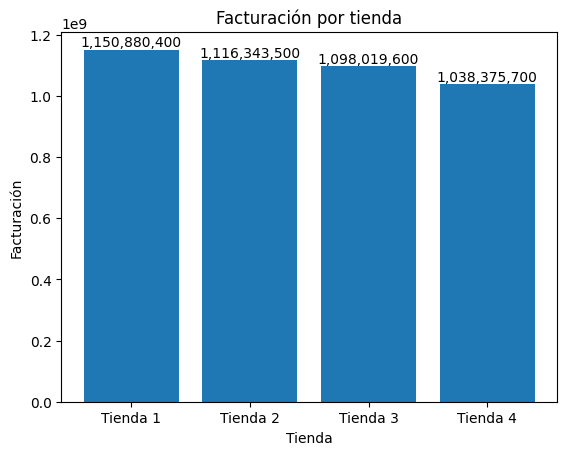

In [ ]:
import matplotlib.pyplot as plt

plt.bar(facturacion["Tienda"], facturacion["Facturacion"])
plt.title("Facturación por tienda")
plt.xlabel("Tienda")
plt.ylabel("Facturación")
for index, value in enumerate(facturacion["Facturacion"]):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')
plt.show()

# 2. Ventas por categoría

In [ ]:
# Ventas por categoría

cat1 = tienda.groupby("Categoría del Producto")["Precio"].sum()
cat2 = tienda2.groupby("Categoría del Producto")["Precio"].sum()
cat3 = tienda3.groupby("Categoría del Producto")["Precio"].sum()
cat4 = tienda4.groupby("Categoría del Producto")["Precio"].sum()

print("Tienda 1")
print(cat1)

print("\nTienda 2")
print(cat2)

print("\nTienda 3")
print(cat3)

print("\nTienda 4")
print(cat4)

Tienda 1
Categoría del Producto
Artículos para el hogar     12698400.0
Deportes y diversión        39290000.0
Electrodomésticos          363685200.0
Electrónicos               429493500.0
Instrumentos musicales      91299000.0
Juguetes                    17995700.0
Libros                       8784900.0
Muebles                    187633700.0
Name: Precio, dtype: float64

Tienda 2
Categoría del Producto
Artículos para el hogar     14746900.0
Deportes y diversión        34744500.0
Electrodomésticos          348567800.0
Electrónicos               410831100.0
Instrumentos musicales     104990300.0
Juguetes                    15945400.0
Libros                      10091200.0
Muebles                    176426300.0
Name: Precio, dtype: float64

Tienda 3
Categoría del Producto
Artículos para el hogar     15060000.0
Deportes y diversión        35593100.0
Electrodomésticos          329237900.0
Electrónicos               410775800.0
Instrumentos musicales      77380900.0
Juguetes                 

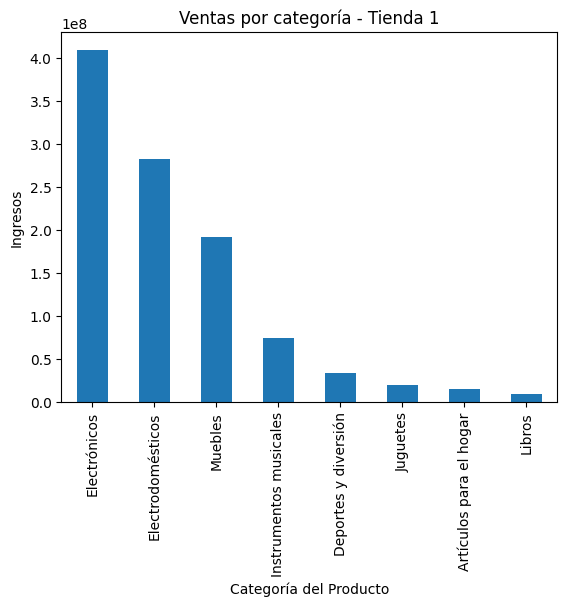

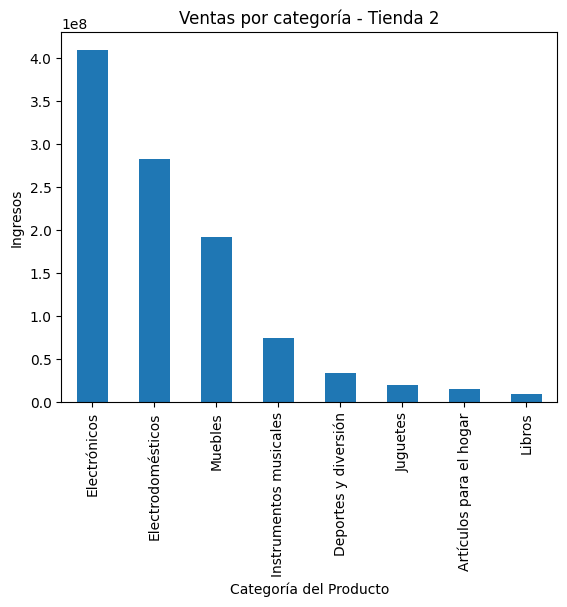

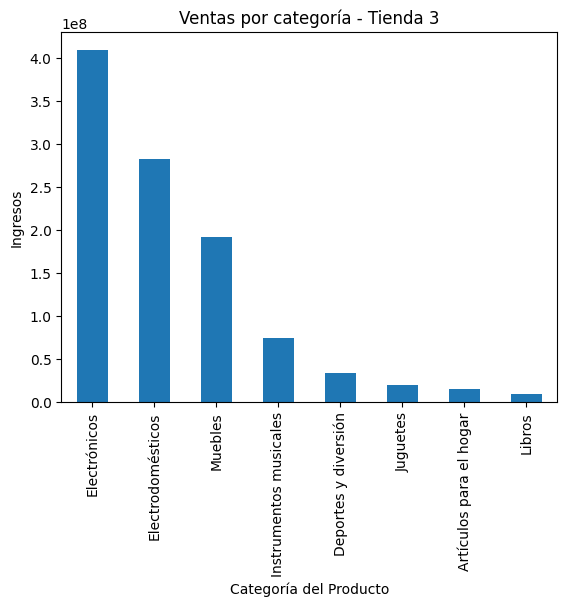

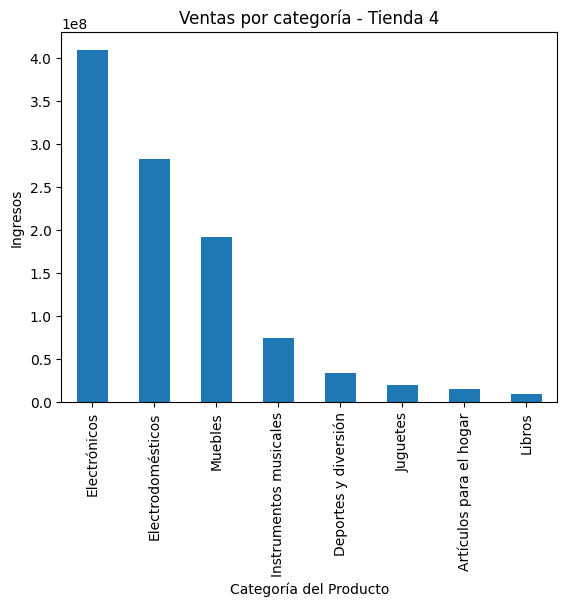

In [ ]:
for nombre, tienda in tiendas.items():

    categoria.plot(kind="bar")
    plt.title(f"Ventas por categoría - {nombre}")
    plt.ylabel("Ingresos")
    plt.show()

# 3. Calificación promedio de la tienda


In [ ]:
cal1 = tienda["Calificación"].mean()
cal2 = tienda2["Calificación"].mean()
cal3 = tienda3["Calificación"].mean()
cal4 = tienda4["Calificación"].mean()

calificaciones = pd.DataFrame({
    "Tienda":["Tienda 1","Tienda 2","Tienda 3","Tienda 4"],
    "Calificacion promedio":[cal1,cal2,cal3,cal4]
})

calificaciones

,Tienda,Calificacion promedio
0,Tienda 1,3.995759
1,Tienda 2,4.037304
2,Tienda 3,4.048326
3,Tienda 4,3.995759


# 4. Productos más y menos vendidos

In [ ]:
# Productos más vendidos

mas_vendidos1 = tienda["Producto"].value_counts().head(5)
menos_vendidos1 = tienda["Producto"].value_counts().tail(5)

print("Más vendidos Tienda 1")
print(mas_vendidos1)

print("\nMenos vendidos Tienda 1")
print(menos_vendidos1)

Más vendidos Tienda 1
Producto
Cama box                     62
Cubertería                   59
Dashboards con Power BI      56
Cama king                    56
Carrito de control remoto    55
Name: count, dtype: int64

Menos vendidos Tienda 1
Producto
Refrigerador                   38
Ciencia de datos con Python    38
Guitarra acústica              37
Armario                        34
Guitarra eléctrica             33
Name: count, dtype: int64


# 5. Envío promedio por tienda

,Tienda,Envio promedio
0,Tienda 1,23459.457167
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


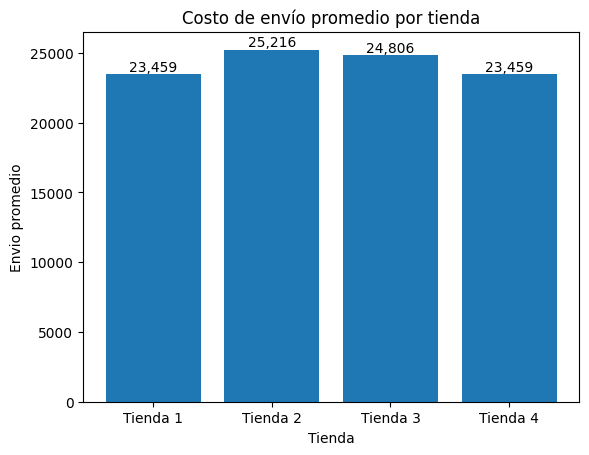

In [ ]:
import matplotlib.pyplot as plt

envio1 = tienda["Costo de envío"].mean()
envio2 = tienda2["Costo de envío"].mean()
envio3 = tienda3["Costo de envío"].mean()
envio4 = tienda4["Costo de envío"].mean()

envios = pd.DataFrame({
    "Tienda":["Tienda 1","Tienda 2","Tienda 3","Tienda 4"],
    "Envio promedio":[envio1,envio2,envio3,envio4]
})

display(envios)

plt.bar(envios["Tienda"], envios["Envio promedio"])
plt.title("Costo de envío promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Envio promedio")
for index, value in enumerate(envios["Envio promedio"]):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')
plt.show()